<a href="https://colab.research.google.com/github/asetya/BigData/blob/master/ORB_imageMatching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from skimage import data
from skimage import transform
from skimage.feature import match_descriptors, ORB
#from skimage.feature.plot_matches import plot_matches # Removed import
from skimage.color import rgb2gray
import matplotlib.pyplot as plt
# Import necessary modules for manual plotting
from matplotlib.patches import ConnectionPatch
import numpy as np

In [3]:
import skimage
print(skimage.__version__)

0.25.2


In [9]:


img1 = rgb2gray(data.astronaut())
img2 = transform.rotate(img1, 180)
tform = transform.AffineTransform(scale=(1.3, 1.1), rotation=0.5,
                                  translation=(0, -200))
img3 = transform.warp(img1, tform)

descriptor_extractor = ORB(n_keypoints=200)

descriptor_extractor.detect_and_extract(img1)
keypoints1 = descriptor_extractor.keypoints
descriptors1 = descriptor_extractor.descriptors

descriptor_extractor.detect_and_extract(img2)
keypoints2 = descriptor_extractor.keypoints
descriptors2 = descriptor_extractor.descriptors

descriptor_extractor.detect_and_extract(img3)
keypoints3 = descriptor_extractor.keypoints
descriptors3 = descriptor_extractor.descriptors



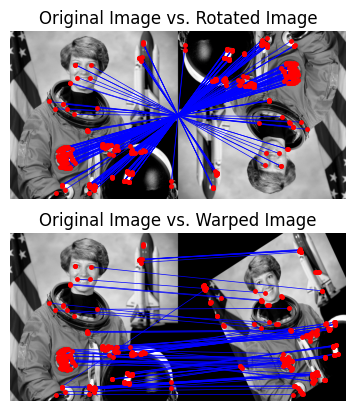

In [10]:
matches12 = match_descriptors(descriptors1, descriptors2, cross_check=True)
matches13 = match_descriptors(descriptors1, descriptors3, cross_check=True)

fig, ax = plt.subplots(nrows=2, ncols=1)

plt.gray()

# Function to plot matches manually
def plot_manual_matches(ax, image1, image2, keypoints1, keypoints2, matches):
    image1_height, image1_width = image1.shape[:2]
    image2_height, image2_width = image2.shape[:2]

    # Create a combined image for plotting
    combined_image = np.hstack((image1, image2))
    ax.imshow(combined_image)

    # Plot keypoints
    ax.plot(keypoints1[:, 1], keypoints1[:, 0], 'r.', markersize=5)
    ax.plot(keypoints2[:, 1] + image1_width, keypoints2[:, 0], 'r.', markersize=5)

    # Plot matches
    for m in matches:
        p1 = keypoints1[m[0]]
        p2 = keypoints2[m[1]]
        con = ConnectionPatch(xyA=(p1[1], p1[0]), xyB=(p2[1] + image1_width, p2[0]),
                              coordsA="data", coordsB="data",
                              axesA=ax, axesB=ax, color="blue", linewidth=0.5)
        ax.add_patch(con)


# Replace plot_matches with manual plotting
plot_manual_matches(ax[0], img1, img2, keypoints1, keypoints2, matches12)
ax[0].axis('off')
ax[0].set_title("Original Image vs. Rotated Image") # Corrected title

plot_manual_matches(ax[1], img1, img3, keypoints1, keypoints3, matches13)
ax[1].axis('off')
ax[1].set_title("Original Image vs. Warped Image") # Corrected title


plt.show()